# Task 3: Car Price Prediction with Machine Learning

Complete workflow: loading, cleaning, EDA, feature engineering, correlation-based feature removal, preprocessing, model comparison, tuning, evaluation, feature importance, model saving, and new predictions.

In [1]:
import os, warnings, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, KFold, cross_validate, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.inspection import permutation_importance
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
RANDOM_STATE=42

## 1. Load the dataset
The notebook first checks your Windows path, then its own folder.

In [2]:
DATA_PATHS=[r'G:\Code Alpha Intership 2026\Task No 3\car data.csv','car data.csv','/mnt/data/car data.csv']
data_path=next((x for x in DATA_PATHS if os.path.exists(x)),None)
if data_path is None:
    raise FileNotFoundError("Place 'car data.csv' beside this notebook or edit DATA_PATHS.")
df=pd.read_csv(data_path)
print('Loaded:',data_path,'Shape:',df.shape)
display(df.head())

Loaded: G:\Code Alpha Intership 2026\Task No 3\car data.csv Shape: (301, 9)


,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


## 2. Inspect and clean the data

In [3]:
df.info()
display(df.describe(include='all').T)
quality=pd.DataFrame({'dtype':df.dtypes.astype(str),'missing':df.isna().sum(),'missing_%':(df.isna().mean()*100).round(2),'unique':df.nunique(dropna=False)})
display(quality)
print('Duplicate rows:',df.duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    str    
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    str    
 6   Selling_type   301 non-null    str    
 7   Transmission   301 non-null    str    
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 21.3 KB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Car_Name,301,98,city,26,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,301.0,NaN,NaN,NaN,2013.627907,2.891554,2003.0,2012.0,2014.0,2016.0,2018.0
Selling_Price,301.0,NaN,NaN,NaN,4.661296,5.082812,0.1,0.9,3.6,6.0,35.0
Present_Price,301.0,NaN,NaN,NaN,7.628472,8.642584,0.32,1.2,6.4,9.9,92.6
Driven_kms,301.0,NaN,NaN,NaN,36947.20598,38886.883882,500.0,15000.0,32000.0,48767.0,500000.0
Fuel_Type,301,3,Petrol,239,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Selling_type,301,2,Dealer,195,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Transmission,301,2,Manual,261,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Owner,301.0,NaN,NaN,NaN,0.043189,0.247915,0.0,0.0,0.0,0.0,3.0


,dtype,missing,missing_%,unique
Car_Name,str,0,0.0,98
Year,int64,0,0.0,16
Selling_Price,float64,0,0.0,156
Present_Price,float64,0,0.0,148
Driven_kms,int64,0,0.0,206
Fuel_Type,str,0,0.0,3
Selling_type,str,0,0.0,2
Transmission,str,0,0.0,2
Owner,int64,0,0.0,3


Duplicate rows: 2


In [4]:
data=df.copy()
data.columns=data.columns.str.strip()
data=data.drop_duplicates().reset_index(drop=True)
for col in data.select_dtypes('object'):
    data[col]=data[col].astype(str).str.strip()
for col in ['Year','Selling_Price','Present_Price','Driven_kms','Owner']:
    if col in data: data[col]=pd.to_numeric(data[col],errors='coerce')
for col in ['Selling_Price','Present_Price','Driven_kms','Owner']:
    if col in data: data.loc[data[col]<0,col]=np.nan
data=data.dropna(subset=['Selling_Price']).reset_index(drop=True)
print('Cleaned shape:',data.shape)

Cleaned shape: (299, 9)


## 3. Feature engineering
Create `Car_Age` and extract a simple `Brand` from `Car_Name`.

In [5]:
REFERENCE_YEAR=int(data['Year'].max())+1
data['Car_Age']=REFERENCE_YEAR-data['Year']
data['Brand']=data['Car_Name'].str.lower().str.split().str[0].fillna('unknown')
data.loc[data['Car_Age']<0,'Car_Age']=np.nan
display(data[['Car_Name','Brand','Year','Car_Age']].head(10))

,Car_Name,Brand,Year,Car_Age
0,ritz,ritz,2014,5.0
1,sx4,sx4,2013,6.0
2,ciaz,ciaz,2017,2.0
3,wagon r,wagon,2011,8.0
4,swift,swift,2014,5.0
5,vitara brezza,vitara,2018,1.0
6,ciaz,ciaz,2015,4.0
7,s cross,s,2015,4.0
8,ciaz,ciaz,2016,3.0
9,ciaz,ciaz,2015,4.0


## 4. Exploratory data analysis

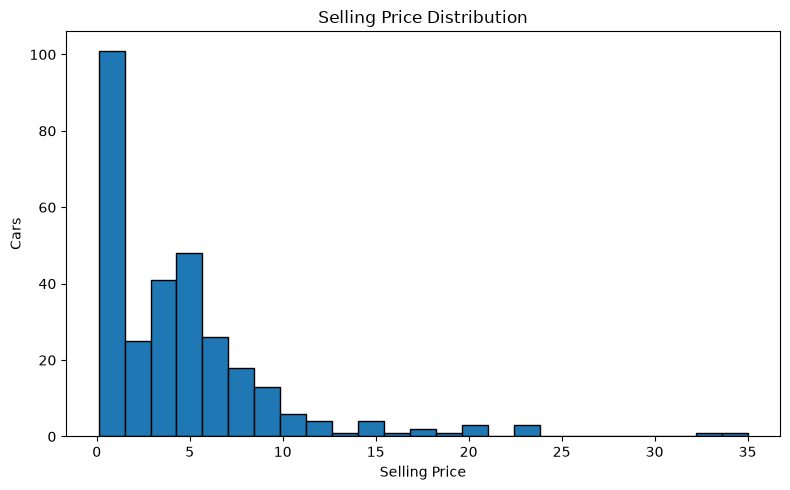

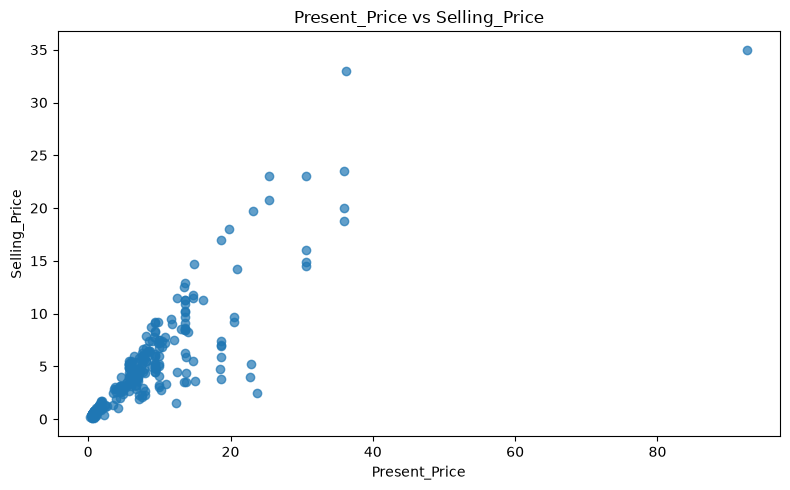

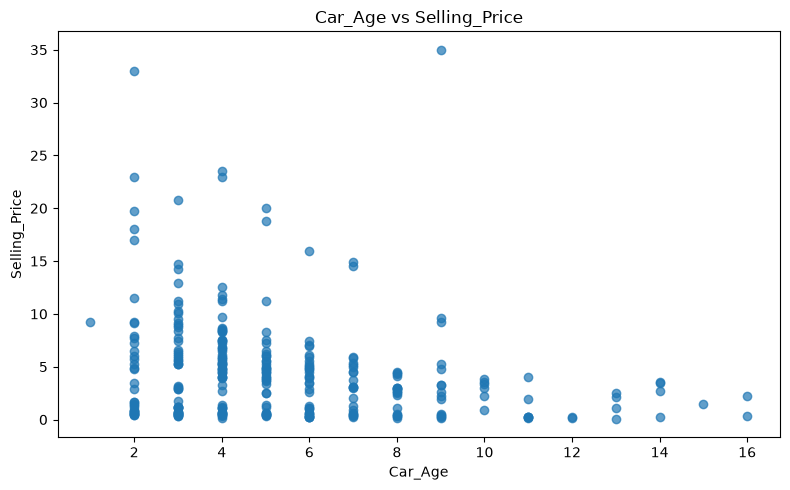

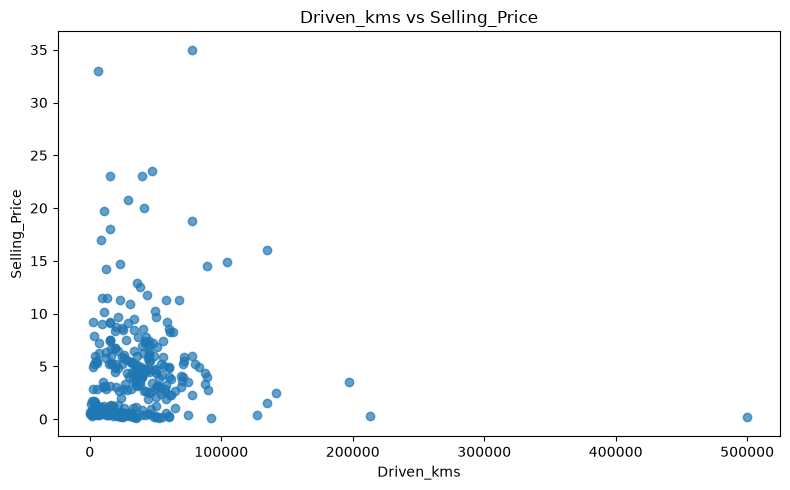

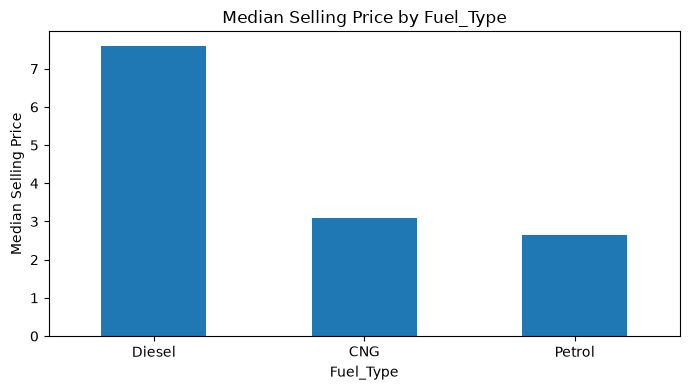

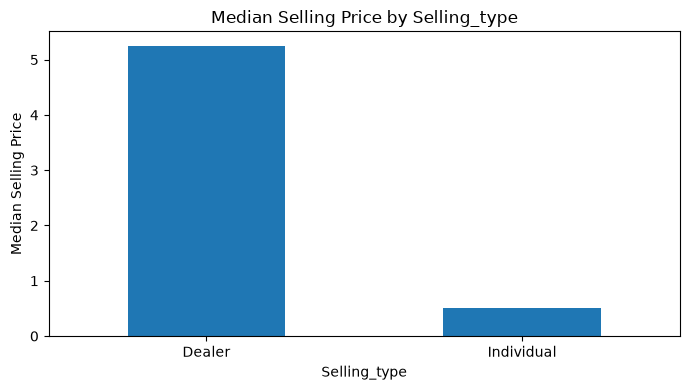

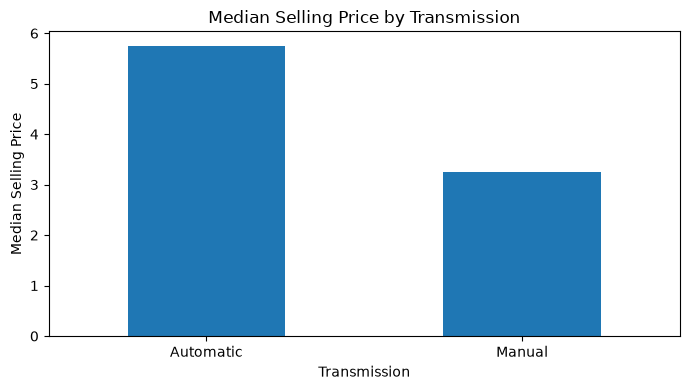

In [6]:
figures=[('Selling_Price',None),('Present_Price','Selling_Price'),('Car_Age','Selling_Price'),('Driven_kms','Selling_Price')]
plt.figure(figsize=(8,5)); plt.hist(data['Selling_Price'],bins=25,edgecolor='black'); plt.title('Selling Price Distribution'); plt.xlabel('Selling Price'); plt.ylabel('Cars'); plt.tight_layout(); plt.show()
for x,y in figures[1:]:
    plt.figure(figsize=(8,5)); plt.scatter(data[x],data[y],alpha=.7); plt.title(f'{x} vs {y}'); plt.xlabel(x); plt.ylabel(y); plt.tight_layout(); plt.show()
for col in ['Fuel_Type','Selling_type','Transmission']:
    if col in data:
        g=data.groupby(col)['Selling_Price'].median().sort_values(ascending=False)
        plt.figure(figsize=(7,4)); g.plot(kind='bar'); plt.title(f'Median Selling Price by {col}'); plt.ylabel('Median Selling Price'); plt.xticks(rotation=0); plt.tight_layout(); plt.show()

## 5. Correlation analysis and redundant-feature removal
Numerical predictor pairs above 0.90 absolute correlation are flagged. `Year` is removed because it is perfectly redundant with `Car_Age`.

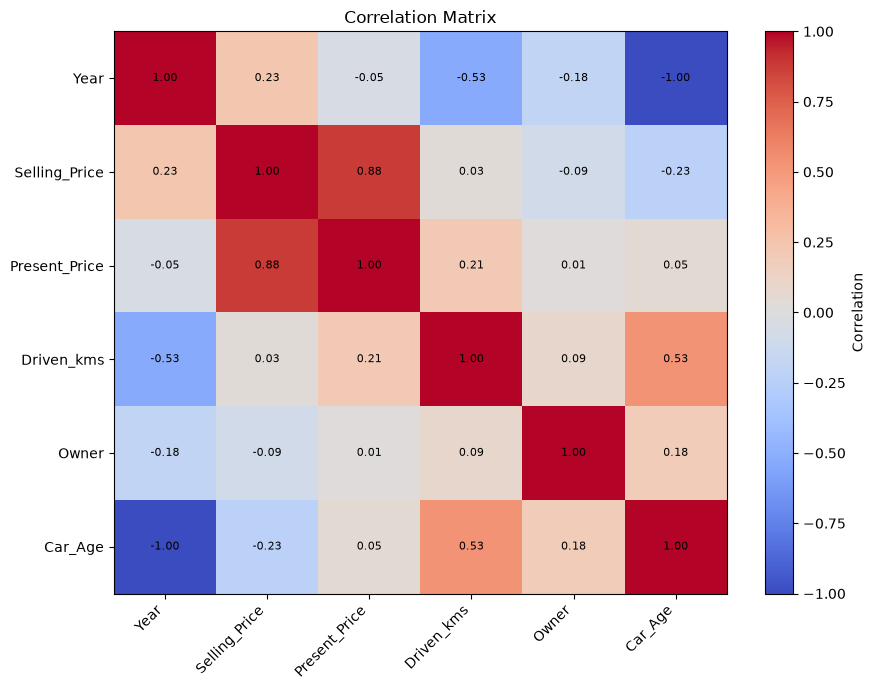

,Correlation_with_target
Present_Price,0.876305
Year,0.234369
Car_Age,-0.234369
Owner,-0.087880
Driven_kms,0.028566


,Feature_1,Feature_2,Abs_Correlation
0,Year,Car_Age,1.0


Removed: ['Year']


In [7]:
num=data.select_dtypes(include=np.number)
corr=num.corr()
plt.figure(figsize=(9,7)); im=plt.imshow(corr,cmap='coolwarm',vmin=-1,vmax=1,aspect='auto'); plt.colorbar(im,label='Correlation'); plt.xticks(range(len(corr.columns)),corr.columns,rotation=45,ha='right'); plt.yticks(range(len(corr.index)),corr.index)
for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        plt.text(j,i,f'{corr.iloc[i,j]:.2f}',ha='center',va='center',fontsize=8)
plt.title('Correlation Matrix'); plt.tight_layout(); plt.show()
display(corr['Selling_Price'].drop('Selling_Price').sort_values(key=abs,ascending=False).to_frame('Correlation_with_target'))
TARGET='Selling_Price'; THRESHOLD=.90
pred_num=num.drop(columns=[TARGET],errors='ignore')
upper=pred_num.corr().abs().where(np.triu(np.ones((pred_num.shape[1],pred_num.shape[1])),k=1).astype(bool))
pairs=[]
for col in upper.columns:
    for row in upper.index:
        v=upper.loc[row,col]
        if pd.notna(v) and v>THRESHOLD: pairs.append((row,col,v))
if pairs: display(pd.DataFrame(pairs,columns=['Feature_1','Feature_2','Abs_Correlation']))
features_to_drop=[]
if 'Year' in pred_num and 'Car_Age' in pred_num and abs(pred_num['Year'].corr(pred_num['Car_Age']))>THRESHOLD: features_to_drop.append('Year')
for a,b,v in pairs:
    if {a,b}!={'Year','Car_Age'} and b not in features_to_drop: features_to_drop.append(b)
print('Removed:',features_to_drop)

## 6. Define features, split data, and build preprocessing

In [8]:
X=data.drop(columns=[TARGET,'Car_Name',*features_to_drop],errors='ignore')
y=data[TARGET]
print('Features:',X.columns.tolist())
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=.20,random_state=RANDOM_STATE)
num_features=X.select_dtypes(include=np.number).columns.tolist()
cat_features=X.select_dtypes(exclude=np.number).columns.tolist()
try: encoder=OneHotEncoder(handle_unknown='ignore',sparse_output=False)
except TypeError: encoder=OneHotEncoder(handle_unknown='ignore',sparse=False)
preprocessor=ColumnTransformer([
 ('num',Pipeline([('imputer',SimpleImputer(strategy='median')),('scaler',StandardScaler())]),num_features),
 ('cat',Pipeline([('imputer',SimpleImputer(strategy='most_frequent')),('onehot',encoder)]),cat_features)
])
print('Train:',X_train.shape,'Test:',X_test.shape)

Features: ['Present_Price', 'Driven_kms', 'Fuel_Type', 'Selling_type', 'Transmission', 'Owner', 'Car_Age', 'Brand']
Train: (239, 8) Test: (60, 8)


## 7. Compare regression models with five-fold cross-validation

,Model,CV_MAE,CV_RMSE,CV_R2_Mean,CV_R2_Std,Test_MAE,Test_RMSE,Test_R2
0,Random Forest,0.676729,1.487493,0.900378,0.079274,1.364832,3.291778,0.579572
1,Extra Trees,0.671115,1.508502,0.899439,0.092909,0.815729,1.731821,0.883631
2,Gradient Boosting,0.703372,1.554011,0.890037,0.103500,1.149834,2.610618,0.735566
3,Ridge Regression,1.088038,1.723702,0.875252,0.035110,1.345228,2.403744,0.775815
4,Lasso Regression,1.081523,1.816380,0.862618,0.063329,1.438891,2.509762,0.755603
5,Linear Regression,1.106889,1.916755,0.846466,0.084967,1.473766,2.793936,0.697125


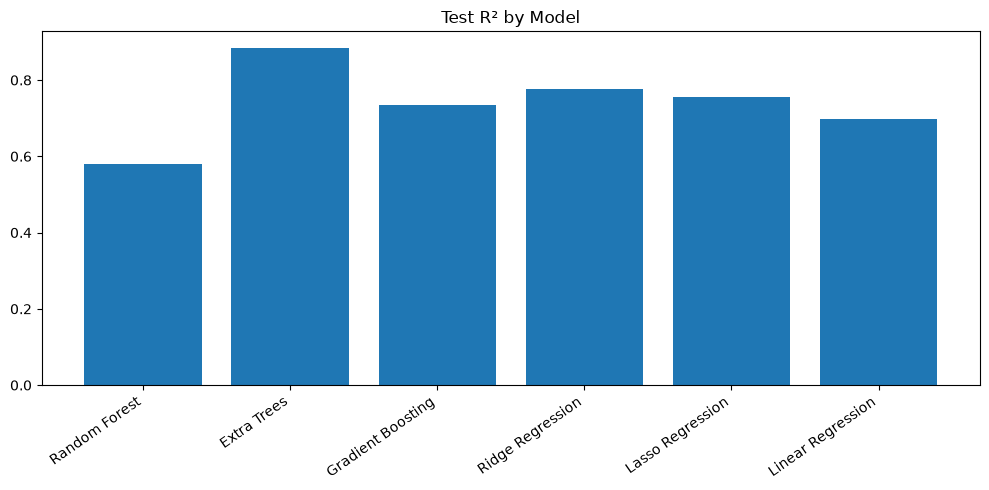

In [9]:
models={
 'Linear Regression':LinearRegression(),
 'Ridge Regression':Ridge(alpha=1.0),
 'Lasso Regression':Lasso(alpha=.01,max_iter=10000),
 'Random Forest':RandomForestRegressor(n_estimators=150,random_state=RANDOM_STATE,n_jobs=-1),
 'Extra Trees':ExtraTreesRegressor(n_estimators=150,random_state=RANDOM_STATE,n_jobs=-1),
 'Gradient Boosting':GradientBoostingRegressor(random_state=RANDOM_STATE)}
cv=KFold(n_splits=5,shuffle=True,random_state=RANDOM_STATE)
rows=[]; fitted={}
for name,est in models.items():
    pipe=Pipeline([('preprocessor',clone(preprocessor)),('model',clone(est))])
    scores=cross_validate(pipe,X_train,y_train,cv=cv,scoring={'mae':'neg_mean_absolute_error','rmse':'neg_root_mean_squared_error','r2':'r2'},n_jobs=-1)
    pipe.fit(X_train,y_train); pred=pipe.predict(X_test)
    rows.append({'Model':name,'CV_MAE':-scores['test_mae'].mean(),'CV_RMSE':-scores['test_rmse'].mean(),'CV_R2_Mean':scores['test_r2'].mean(),'CV_R2_Std':scores['test_r2'].std(),'Test_MAE':mean_absolute_error(y_test,pred),'Test_RMSE':np.sqrt(mean_squared_error(y_test,pred)),'Test_R2':r2_score(y_test,pred)})
    fitted[name]=pipe
results_df=pd.DataFrame(rows).sort_values(['CV_R2_Mean','Test_R2'],ascending=False).reset_index(drop=True)
display(results_df)
plt.figure(figsize=(10,5)); plt.bar(results_df['Model'],results_df['Test_R2']); plt.title('Test R² by Model'); plt.xticks(rotation=35,ha='right'); plt.tight_layout(); plt.show()

## 8. Tune the strongest tree-based model

In [10]:
tree_names=['Random Forest','Extra Trees','Gradient Boosting']
base=results_df[results_df['Model'].isin(tree_names)].iloc[0]['Model']
if base=='Random Forest':
    est=RandomForestRegressor(random_state=RANDOM_STATE,n_jobs=-1)
    params={'model__n_estimators':[150,300,500],'model__max_depth':[None,4,6,8,12],'model__min_samples_split':[2,4,6],'model__min_samples_leaf':[1,2,3],'model__max_features':[1.0,'sqrt']}
elif base=='Extra Trees':
    est=ExtraTreesRegressor(random_state=RANDOM_STATE,n_jobs=-1)
    params={'model__n_estimators':[150,300,500],'model__max_depth':[None,4,6,8,12],'model__min_samples_split':[2,4,6],'model__min_samples_leaf':[1,2,3],'model__max_features':[1.0,'sqrt']}
else:
    est=GradientBoostingRegressor(random_state=RANDOM_STATE)
    params={'model__n_estimators':[100,200,300],'model__learning_rate':[.01,.03,.05,.1],'model__max_depth':[2,3,4],'model__min_samples_split':[2,4,6],'model__min_samples_leaf':[1,2,3],'model__subsample':[.7,.85,1.0]}
search=RandomizedSearchCV(Pipeline([('preprocessor',clone(preprocessor)),('model',est)]),params,n_iter=10,scoring='r2',cv=cv,random_state=RANDOM_STATE,n_jobs=-1)
search.fit(X_train,y_train)
best_model=search.best_estimator_; best_pred=best_model.predict(X_test)
print('Tuned model:',base); print('Best parameters:',search.best_params_); print('CV R²:',round(search.best_score_,4)); print('Test MAE:',round(mean_absolute_error(y_test,best_pred),4)); print('Test RMSE:',round(np.sqrt(mean_squared_error(y_test,best_pred)),4)); print('Test R²:',round(r2_score(y_test,best_pred),4))

Tuned model: Random Forest
Best parameters: {'model__n_estimators': 500, 'model__min_samples_split': 6, 'model__min_samples_leaf': 1, 'model__max_features': 1.0, 'model__max_depth': 6}
CV R²: 0.8935
Test MAE: 1.412
Test RMSE: 3.366
Test R²: 0.5604


## 9. Actual vs predicted, residuals, and largest errors

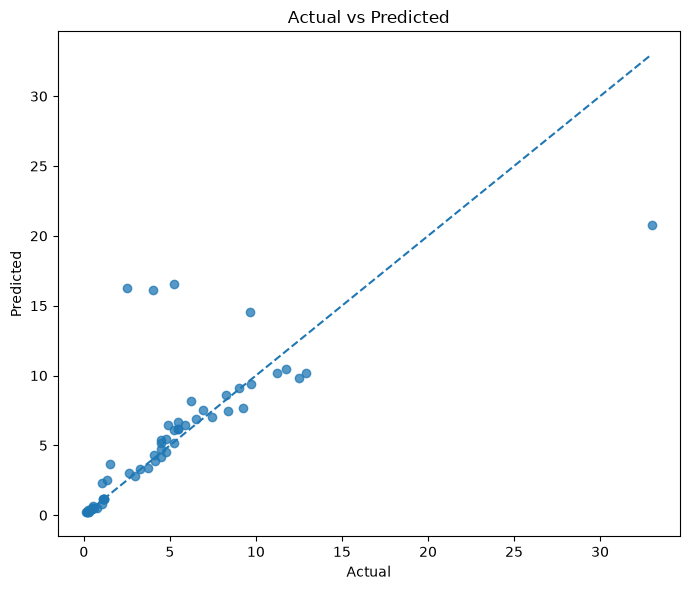

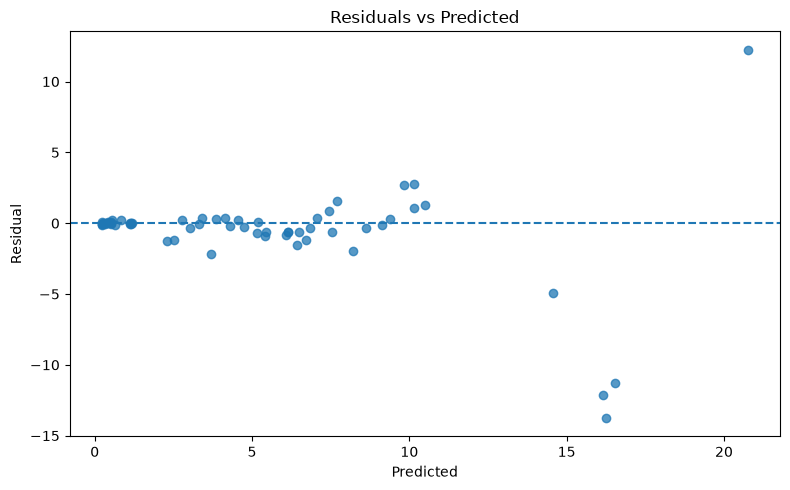

,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age,Brand,Actual_Selling_Price,Predicted_Selling_Price,Residual,Absolute_Error
84,23.73,142000.0,Petrol,Individual,Automatic,3.0,13.0,camry,2.50,16.257541,-13.757541,13.757541
63,36.23,6000.0,Diesel,Dealer,Automatic,0.0,2.0,fortuner,33.00,20.754533,12.245467,12.245467
92,22.78,89000.0,Petrol,Dealer,Automatic,0.0,11.0,corolla,4.00,16.150329,-12.150329,12.150329
77,22.83,80000.0,Petrol,Dealer,Automatic,0.0,9.0,corolla,5.25,16.535740,-11.285740,11.285740
97,20.45,50024.0,Diesel,Dealer,Manual,0.0,9.0,fortuner,9.65,14.577625,-4.927625,4.927625
248,13.60,35934.0,Diesel,Dealer,Manual,0.0,3.0,creta,12.90,10.149255,2.750745,2.750745
82,13.46,38000.0,Diesel,Dealer,Manual,0.0,4.0,innova,12.50,9.817476,2.682524,2.682524
76,12.35,135154.0,Petrol,Dealer,Automatic,0.0,15.0,corolla,1.50,3.683174,-2.183174,2.183174
277,13.60,40126.0,Petrol,Dealer,Manual,0.0,5.0,city,6.25,8.209207,-1.959207,1.959207
5,9.83,2071.0,Diesel,Dealer,Manual,0.0,1.0,vitara,9.25,7.711387,1.538613,1.538613


In [11]:
lo=min(y_test.min(),best_pred.min()); hi=max(y_test.max(),best_pred.max())
plt.figure(figsize=(7,6)); plt.scatter(y_test,best_pred,alpha=.75); plt.plot([lo,hi],[lo,hi],'--'); plt.title('Actual vs Predicted'); plt.xlabel('Actual'); plt.ylabel('Predicted'); plt.tight_layout(); plt.show()
residuals=y_test.to_numpy()-best_pred
plt.figure(figsize=(8,5)); plt.scatter(best_pred,residuals,alpha=.75); plt.axhline(0,linestyle='--'); plt.title('Residuals vs Predicted'); plt.xlabel('Predicted'); plt.ylabel('Residual'); plt.tight_layout(); plt.show()
prediction_results=X_test.copy(); prediction_results['Actual_Selling_Price']=y_test; prediction_results['Predicted_Selling_Price']=best_pred; prediction_results['Residual']=prediction_results['Actual_Selling_Price']-prediction_results['Predicted_Selling_Price']; prediction_results['Absolute_Error']=prediction_results['Residual'].abs(); prediction_results=prediction_results.sort_values('Absolute_Error',ascending=False)
display(prediction_results.head(15))

## 10. Permutation feature importance

,Feature,Importance_Mean,Importance_Std
0,Present_Price,1.314859e+00,2.281106e-01
6,Car_Age,2.034757e-01,5.899308e-02
1,Driven_kms,4.640187e-02,1.338543e-02
4,Transmission,1.182505e-02,4.492520e-03
2,Fuel_Type,4.140757e-03,1.489960e-03
7,Brand,2.223754e-03,2.267660e-03
3,Selling_type,1.445711e-03,4.022346e-04
5,Owner,-4.490534e-08,7.378796e-08


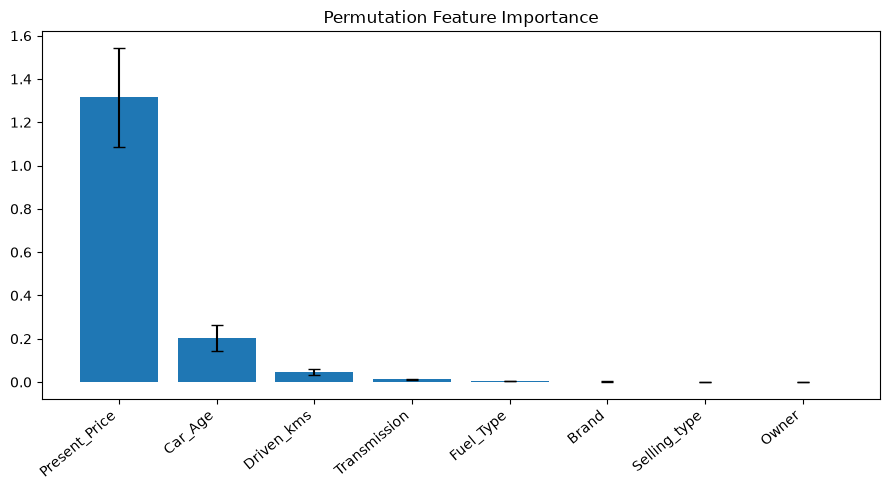

In [12]:
imp=permutation_importance(best_model,X_test,y_test,scoring='r2',n_repeats=8,random_state=RANDOM_STATE,n_jobs=-1)
importance_df=pd.DataFrame({'Feature':X_test.columns,'Importance_Mean':imp.importances_mean,'Importance_Std':imp.importances_std}).sort_values('Importance_Mean',ascending=False)
display(importance_df)
plt.figure(figsize=(9,5)); plt.bar(importance_df['Feature'],importance_df['Importance_Mean'],yerr=importance_df['Importance_Std'],capsize=4); plt.title('Permutation Feature Importance'); plt.xticks(rotation=40,ha='right'); plt.tight_layout(); plt.show()

## 11. Save outputs and predict a new car

In [13]:
joblib.dump(best_model,'car_price_prediction_model.joblib')
results_df.to_csv('car_price_model_comparison.csv',index=False)
prediction_results.to_csv('car_price_test_predictions.csv',index=False)
importance_df.to_csv('car_price_feature_importance.csv',index=False)
print('Saved model and CSV files in:',os.getcwd())
new_car=pd.DataFrame([{'Present_Price':8.5,'Driven_kms':35000,'Fuel_Type':'Petrol','Selling_type':'Dealer','Transmission':'Manual','Owner':0,'Car_Age':5,'Brand':'maruti'}]).reindex(columns=X.columns)
print('Predicted selling price:',round(best_model.predict(new_car)[0],2))
display(new_car)

Saved model and CSV files in: G:\Code Alpha Intership 2026\Task No 3


Predicted selling price: 6.28


,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age,Brand
0,8.5,35000,Petrol,Dealer,Manual,0,5,maruti


## Conclusion
This notebook provides a complete, leakage-safe car-price prediction workflow. It removes redundant correlation, compares several models, tunes the best ensemble, evaluates errors, explains feature importance, and saves a reusable trained pipeline.